In [ ]:
# ============================================================
# STEP 0: IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
import string
from collections import Counter

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings("ignore")



In [ ]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:

# ============================================================
# STEP 1: LOAD DATA
# ============================================================

df = pd.read_csv('/content/Reviews.csv', on_bad_lines='skip', encoding='latin1', engine='python')

df = df[['Text', 'Summary', 'Score',
         'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Time']]

df.dropna(inplace=True)

print("Dataset Shape:", df.shape)


Dataset Shape: (40249, 6)


In [ ]:
df

,Text,Summary,Score,HelpfulnessNumerator,HelpfulnessDenominator,Time
0,I have bought several of the Vitality canned d...,Good Quality Dog Food,5,1,1,1303862400
1,Product arrived labeled as Jumbo Salted Peanut...,Not as Advertised,1,0,0,1346976000
2,This is a confection that has been around a fe...,"""Delight"" says it all",4,1,1,1219017600
3,If you are looking for the secret ingredient i...,Cough Medicine,2,3,3,1307923200
4,Great taffy at a great price. There was a wid...,Great taffy,5,0,0,1350777600
...,...,...,...,...,...,...
40245,"We purchased a Keurig last Christmas holiday, ...",Best milk chocolate available for Keurig,4,0,1,1284854400
40246,I ordered this after I tried the Green Mountai...,Will not be drinking.....,1,0,1,1281052800
40247,"Saw this is the local market, figured for $7 I...",save your money,1,3,6,1267228800
40248,I was pretty excited when I bought the B70 for...,Tastes like hot water with some chocolate in it,1,0,2,1293580800


In [ ]:
print(df.head())
print(df.shape)
print(df.info())
print(df.isnull().sum())


                                                Text                Summary  \
0  I have bought several of the Vitality canned d...  Good Quality Dog Food   
1  Product arrived labeled as Jumbo Salted Peanut...      Not as Advertised   
2  This is a confection that has been around a fe...  "Delight" says it all   
3  If you are looking for the secret ingredient i...         Cough Medicine   
4  Great taffy at a great price.  There was a wid...            Great taffy   

   Score  HelpfulnessNumerator  HelpfulnessDenominator        Time  
0      5                     1                       1  1303862400  
1      1                     0                       0  1346976000  
2      4                     1                       1  1219017600  
3      2                     3                       3  1307923200  
4      5                     0                       0  1350777600  
(40249, 6)
<class 'pandas.core.frame.DataFrame'>
Index: 40249 entries, 0 to 40249
Data columns (total 6 columns

In [ ]:
df = df[['Text', 'Score']]
df.dropna(inplace=True)

In [ ]:
def sentiment_label(score):
    if score <= 2:
        return 'Negative'
    elif score == 3:
        return 'Neutral'
    else:
        return 'Positive'

df['Sentiment'] = df['Score'].apply(sentiment_label)


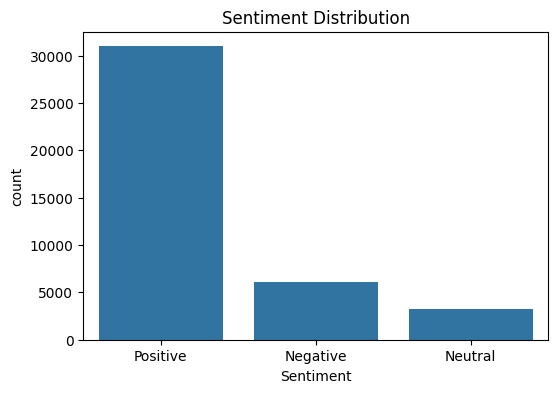

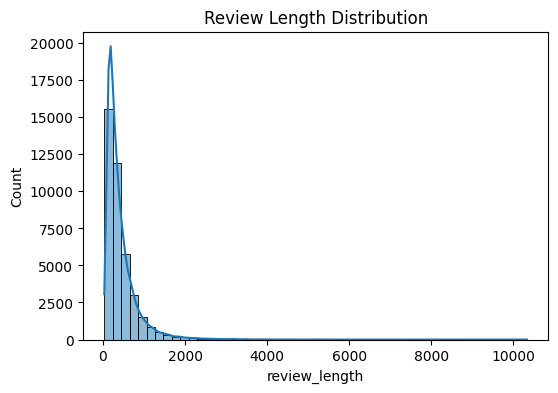

Sentiment
Negative    482.708771
Neutral     513.599937
Positive    409.860451
Name: review_length, dtype: float64


In [ ]:
# 8.1 Sentiment distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()

# 8.2 Review length analysis
df['review_length'] = df['Text'].apply(len)

plt.figure(figsize=(6,4))
sns.histplot(df['review_length'], bins=50, kde=True)
plt.title("Review Length Distribution")
plt.show()

# 8.3 Average length by sentiment
print(df.groupby('Sentiment')['review_length'].mean())

In [ ]:
def remove_html(text):
    return re.sub(r'<.*?>', '', text)

def remove_urls(text):
    return re.sub(r'http\S+|www\S+', '', text)

def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

def remove_numbers(text):
    return re.sub(r'\d+', '', text)

def remove_stopwords(text):
    words = word_tokenize(text)
    return " ".join([w for w in words if w not in stop_words])

def clean_text(text):
    text = str(text).lower()
    text = remove_html(text)
    text = remove_urls(text)
    text = remove_punctuation(text)
    text = remove_numbers(text)
    text = remove_stopwords(text)
    return text

df['cleaned_text'] = df['Text'].apply(clean_text)

In [ ]:
df

,Text,Score,Sentiment,review_length,cleaned_text
0,I have bought several of the Vitality canned d...,5,Positive,263,bought several vitality canned dog food produc...
1,Product arrived labeled as Jumbo Salted Peanut...,1,Negative,190,product arrived labeled jumbo salted peanutsth...
2,This is a confection that has been around a fe...,4,Positive,509,confection around centuries light pillowy citr...
3,If you are looking for the secret ingredient i...,2,Negative,219,looking secret ingredient robitussin believe f...
4,Great taffy at a great price. There was a wid...,5,Positive,140,great taffy great price wide assortment yummy ...
...,...,...,...,...,...
40245,"We purchased a Keurig last Christmas holiday, ...",4,Positive,1192,purchased keurig last christmas holiday please...
40246,I ordered this after I tried the Green Mountai...,1,Negative,339,ordered tried green mountain hot chocolate try...
40247,"Saw this is the local market, figured for $7 I...",1,Negative,275,saw local market figured could get pack give i...
40248,I was pretty excited when I bought the B70 for...,1,Negative,791,pretty excited bought b wife likes coffee im h...


In [ ]:
# 10.1 Word count
df['word_count'] = df['cleaned_text'].apply(lambda x: len(x.split()))

# 10.2 Character count
df['char_count'] = df['cleaned_text'].apply(len)

# 10.3 Average word length
df['avg_word_len'] = df['char_count'] / (df['word_count'] + 1)

In [ ]:
df

,Text,Score,Sentiment,review_length,cleaned_text,word_count,char_count,avg_word_len
0,I have bought several of the Vitality canned d...,5,Positive,263,bought several vitality canned dog food produc...,23,164,6.833333
1,Product arrived labeled as Jumbo Salted Peanut...,1,Negative,190,product arrived labeled jumbo salted peanutsth...,18,136,7.157895
2,This is a confection that has been around a fe...,4,Positive,509,confection around centuries light pillowy citr...,40,285,6.951220
3,If you are looking for the secret ingredient i...,2,Negative,219,looking secret ingredient robitussin believe f...,18,128,6.736842
4,Great taffy at a great price. There was a wid...,5,Positive,140,great taffy great price wide assortment yummy ...,13,83,5.928571
...,...,...,...,...,...,...,...,...
40245,"We purchased a Keurig last Christmas holiday, ...",4,Positive,1192,purchased keurig last christmas holiday please...,103,715,6.875000
40246,I ordered this after I tried the Green Mountai...,1,Negative,339,ordered tried green mountain hot chocolate try...,30,207,6.677419
40247,"Saw this is the local market, figured for $7 I...",1,Negative,275,saw local market figured could get pack give i...,27,164,5.857143
40248,I was pretty excited when I bought the B70 for...,1,Negative,791,pretty excited bought b wife likes coffee im h...,85,508,5.906977


In [ ]:
le = LabelEncoder()
df['Sentiment_encoded'] = le.fit_transform(df['Sentiment'])

In [ ]:
df

,Text,Score,Sentiment,review_length,cleaned_text,word_count,char_count,avg_word_len,Sentiment_encoded
0,I have bought several of the Vitality canned d...,5,Positive,263,bought several vitality canned dog food produc...,23,164,6.833333,2
1,Product arrived labeled as Jumbo Salted Peanut...,1,Negative,190,product arrived labeled jumbo salted peanutsth...,18,136,7.157895,0
2,This is a confection that has been around a fe...,4,Positive,509,confection around centuries light pillowy citr...,40,285,6.951220,2
3,If you are looking for the secret ingredient i...,2,Negative,219,looking secret ingredient robitussin believe f...,18,128,6.736842,0
4,Great taffy at a great price. There was a wid...,5,Positive,140,great taffy great price wide assortment yummy ...,13,83,5.928571,2
...,...,...,...,...,...,...,...,...,...
40245,"We purchased a Keurig last Christmas holiday, ...",4,Positive,1192,purchased keurig last christmas holiday please...,103,715,6.875000,2
40246,I ordered this after I tried the Green Mountai...,1,Negative,339,ordered tried green mountain hot chocolate try...,30,207,6.677419,0
40247,"Saw this is the local market, figured for $7 I...",1,Negative,275,saw local market figured could get pack give i...,27,164,5.857143,0
40248,I was pretty excited when I bought the B70 for...,1,Negative,791,pretty excited bought b wife likes coffee im h...,85,508,5.906977,0


In [ ]:
X = df['cleaned_text']
y = df['Sentiment_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
tfidf = TfidfVectorizer(
    max_features=7000,
    ngram_range=(1,2),
    min_df=5
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "SVM": LinearSVC(),
    "Decision Tree": DecisionTreeClassifier(max_depth=20),
    "Random Forest": RandomForestClassifier(n_estimators=200),
}

In [ ]:
results = {}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, preds)
    results[name] = acc

    print("\n", name)
    print("Accuracy:", acc)
    print(classification_report(y_test, preds))



 Logistic Regression
Accuracy: 0.8500621118012422
              precision    recall  f1-score   support

           0       0.75      0.60      0.66      1218
           1       0.50      0.12      0.19       639
           2       0.87      0.98      0.92      6193

    accuracy                           0.85      8050
   macro avg       0.71      0.56      0.59      8050
weighted avg       0.82      0.85      0.82      8050


 Naive Bayes
Accuracy: 0.8115527950310559
              precision    recall  f1-score   support

           0       0.81      0.32      0.46      1218
           1       0.22      0.01      0.02       639
           2       0.81      0.99      0.89      6193

    accuracy                           0.81      8050
   macro avg       0.62      0.44      0.46      8050
weighted avg       0.77      0.81      0.76      8050


 SVM
Accuracy: 0.8472049689440994
              precision    recall  f1-score   support

           0       0.71      0.64      0.67      1218


In [ ]:
best_model = max(results, key=results.get)
print("\nBest Model:", best_model)



Best Model: Logistic Regression


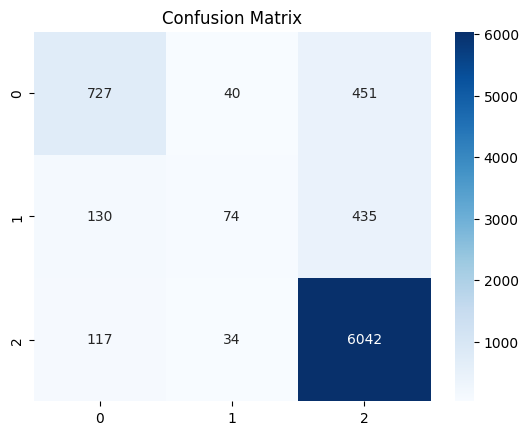

In [ ]:
best_clf = models[best_model]
best_preds = best_clf.predict(X_test_tfidf)

cm = confusion_matrix(y_test, best_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [ ]:
if best_model == "Logistic Regression":
    feature_names = tfidf.get_feature_names_out()
    coef = best_clf.coef_[0]
    top_features = pd.DataFrame({
        'feature': feature_names,
        'weight': coef
    }).sort_values(by='weight', ascending=False)

    print("Top Positive Words")
    print(top_features.head(10))

    print("\nTop Negative Words")
    print(top_features.tail(10))


Top Positive Words
            feature    weight
6868          worst  3.768522
6145       terrible  3.450456
1599   disappointed  3.398633
2964       horrible  3.099819
343           awful  2.971061
1601  disappointing  2.872418
1609     disgusting  2.774284
5134         return  2.597506
6238          threw  2.548690
6712           weak  2.441559

Top Negative Words
        feature    weight
1962  excellent -2.264187
515         bit -2.292791
4509    perfect -2.794555
3657       love -2.875333
458        best -3.007180
3695      loves -3.022707
1472  delicious -3.051416
4129       nice -3.204285
2559       good -3.440746
2675      great -3.997158


In [ ]:

error_df = X_test[y_test != best_preds]
print("Sample Misclassified Reviews:")
print(error_df.head(5))


Sample Misclassified Reviews:
18494    purchased high hopes organic replacement quadr...
31846    usually buy local whole foods harris teeter gr...
34123    tired getting dressing want works perfect keep...
13904    first ingredients list pork byproducts chicken...
7718     bad stuff general ranks high inflammation trig...
Name: cleaned_text, dtype: object


In [ ]:
"""
Conclusion:
- TF-IDF + Linear models perform best
- Random Forest struggles with sparse text
- Review length and wording strongly affect sentiment
"""

'\nConclusion:\n- TF-IDF + Linear models perform best\n- Random Forest struggles with sparse text\n- Review length and wording strongly affect sentiment\n'